# Classical reconstruction and regularization

IDW uses points; Tikhonov minimizes data residual plus squared gradient; TV penalizes absolute gradients; heat regularization performs stable iterative descent. For a fair comparison here, all models receive the same point measurements.

**Objective:** see the influence of regularization on a sharp front.

In [1]:
from pathlib import Path
import os
if Path.cwd().name == 'tutorials': os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from fieldlab import Grid, points, lines, footprints, projections, combine
from fieldlab.fields import simulate, sensor_layout
from fieldlab.operators import observe
from fieldlab.models import idw, tikhonov, gaussian_process, total_variation, heat_reconstruction


IDW RMSE 0.11454504434950029 {}
Tikhonov RMSE 0.10478208694049305 {}
TV RMSE 0.10776204713094459 {'converged': True, 'iterations': 1239, 'message': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH'}
Heat RMSE 0.23610787617199444 {'step_size': 0.0010536082513284114}


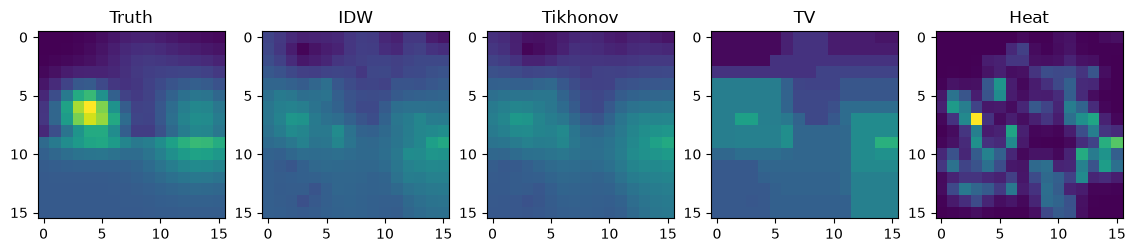

In [2]:
grid=Grid((16,16)); truth=simulate(grid,22,kind='front')
p=np.random.default_rng(3).uniform(0,1,(45,2)); A=points(grid,p); y=observe(A,truth,.03,4)
models={'IDW':idw(grid,p,y),'Tikhonov':tikhonov(grid,A,y),'TV':total_variation(grid,A,y),'Heat':heat_reconstruction(grid,A,y)}
fig,axes=plt.subplots(1,5,figsize=(14,3))
axes[0].imshow(truth,vmin=0,vmax=1); axes[0].set_title('Truth')
for ax,(name,r) in zip(axes[1:],models.items()):
    ax.imshow(r.mean,vmin=0,vmax=1); ax.set_title(name)
    print(name,'RMSE',np.sqrt(np.mean((r.mean-truth)**2)),r.info)
plt.show()


**Exercise:** choose alpha on three separate validation fields, then evaluate on a fourth field. Never choose it using the final truth. Increase noise and explain changes in smoothness. Which estimate preserves a front best? Check TV convergence diagnostics.

See [theory notes](../docs/theory.md) for assumptions and equations.